In [1]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import plotly.express as px
import seaborn as sns

# 📥 Load Data
# Load dataset
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)
df

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50186,Zimbabwe,2019,ZWE,15271377.0,2.514642e+10,0.473,0.031,10.263,-0.942,-8.411,...,NaN,0.106,0.001,0.001,0.002,0.0,34.348,17.531,-0.027,-0.261
50187,Zimbabwe,2020,ZWE,15526888.0,2.317871e+10,0.496,0.032,8.495,-1.768,-17.231,...,NaN,0.105,0.001,0.001,0.002,0.0,31.323,15.775,0.612,7.209
50188,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.531,0.034,10.204,1.709,20.120,...,NaN,0.104,0.001,0.001,0.002,0.0,33.549,17.599,0.539,5.280
50189,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.531,0.033,10.425,0.221,2.169,...,NaN,0.103,0.001,0.001,0.002,0.0,33.772,17.910,0.315,3.018


In [8]:
# ✂️ Filter Top Countries
countries = ['China', 'United States', 'India', 'Russia', 'Japan', 'Germany']
df = df[df['country'].isin(countries)]
df = df[df['year'] >= 1960]

# Drop rows with missing data for key fields
df = df.dropna(subset=['co2_per_capita', 'gdp', 'population', 'share_global_co2'])
df['gdp_per_capita'] = df['gdp'] / df['population']

In [9]:
from ipywidgets import interact
import plotly.graph_objects as go

def plot_3d(year=2020):
    data_year = df[df['year'] == year]
    fig = go.Figure(data=[go.Scatter3d(
        x=data_year['gdp'] / 1e12,  # trillions
        y=data_year['co2'],         # total CO2
        z=data_year['population'] / 1e6,  # millions
        mode='markers+text',
        text=data_year['country'],
        marker=dict(
            size=15,
            color=data_year['co2'],  # color by CO2
            colorscale='Viridis',
            opacity=0.8
        )
    )])
    fig.update_layout(
        scene=dict(
            xaxis_title='GDP (Trillions USD)',
            yaxis_title='Total CO₂ (Mt)',
            zaxis_title='Population (Millions)'
        ),
        title=f'3D CO₂–GDP–Population Visualization ({year})',
        margin=dict(l=0, r=0, b=0, t=30)
    )
    fig.show()

interact(plot_3d, year=sorted(df['year'].unique()))


interactive(children=(Dropdown(description='year', index=60, options=(1960, 1961, 1962, 1963, 1964, 1965, 1966…

<function __main__.plot_3d(year=2020)>

In [3]:
# VIS 1: Animated Bar Chart — Share of Global CO2
df_bar = df[df['year'] >= 1990]

fig1 = px.bar(df_bar,
              x='country',
              y='share_global_co2',
              animation_frame='year',
              color='country',
              title='Share of Global CO₂ Emissions Over Time (1990+)',
              range_y=[0, df_bar['share_global_co2'].max() * 1.1])
fig1.show()


In [4]:
# VIS 2: Interactive Bubble Chart — GDP vs CO2 per capita
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year]

fig2 = px.scatter(df_latest,
                  x='gdp_per_capita',
                  y='co2_per_capita',
                  size='population',
                  color='country',
                  hover_name='country',
                  log_x=True,
                  title=f'GDP vs CO₂ Per Capita ({latest_year})',
                  size_max=60)
fig2.show()


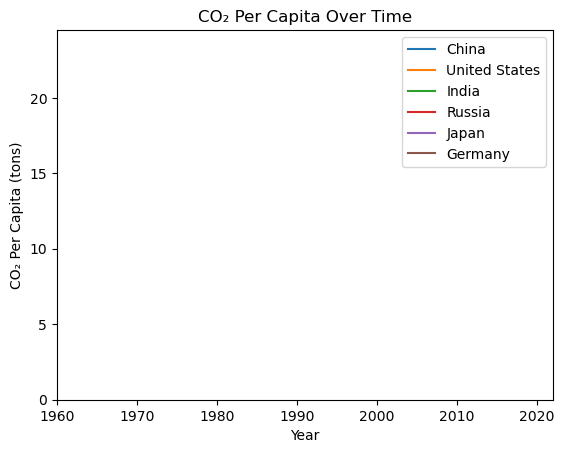

In [5]:
# VIS 3: Animated Line Plot — co2_per_capita over time
fig3, ax3 = plt.subplots()

lines = {c: ax3.plot([], [], label=c)[0] for c in countries}
ax3.set_xlim(df['year'].min(), df['year'].max())
ax3.set_ylim(0, df['co2_per_capita'].max() * 1.1)
ax3.set_title('CO₂ Per Capita Over Time')
ax3.set_xlabel('Year')
ax3.set_ylabel('CO₂ Per Capita (tons)')
ax3.legend()

def animate(i):
    year = df['year'].unique()[i]
    for c in countries:
        sub = df[df['country'] == c]
        x = sub[sub['year'] <= year]['year']
        y = sub[sub['year'] <= year]['co2_per_capita']
        lines[c].set_data(x, y)
    return list(lines.values())

ani = FuncAnimation(fig3, animate, frames=len(df['year'].unique()), interval=200)
HTML(ani.to_jshtml())